# Longitudinal normative modelling

A normative model tells you where a single measurement sits relative to a reference population (a z-score). With **two or more visits per person**, we can go further and ask:

> Did this person change *more than expected* between visits?

This notebook shows the two scores PCNtoolkit provides for that question:

- **z-diff**
- **z-gain**

We use a cross-sectional dataset (`fcon1000`) to build the reference model, and a longitudinal dataset (`LNM_data`, two visits per subject) to score change over time.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pcntoolkit import (
    BLR,
    NormData,
    NormativeModel,
    ZDiffScore,
    ZGainScore,
 )
from pcntoolkit.math_functions.basis_function import (
    BsplineBasisFunction,
 )


def find_data_dir():
    """Locate the example-data folder by searching upward."""
    # Check the current folder and each parent folder in turn.
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "pcntoolkit_resources" / "data"
        # Stop once both files needed by this notebook are found.
        if (
            (candidate / "fcon1000.csv").exists()
            and (candidate / "LNM_data.csv").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not find pcntoolkit_resources/data with "
        "fcon1000.csv and LNM_data.csv"
    )


data_dir = find_data_dir()


def tidy_region_names(df):
    """Use one consistent naming for cortical-thickness columns. Makes sure
    that both datasets have the same column names for the same regions."""
    return df.rename(
        columns={
            c: c.replace("&", "_and_").replace(
                "_thickness", ""
            )
            for c in df.columns
        }
    )


# Choose two cortical-thickness regions
response_vars = ["lh_G_front_middle", "lh_G_and_S_frontomargin"]

## 1. Build the reference model

We fit a normative model of cortical thickness against age on the cross-sectional reference data.

In [2]:
# Load the cross-sectional reference cohort used to fit the model.
reference_df = tidy_region_names(pd.read_csv(data_dir / "fcon1000.csv"))

reference_data = NormData.from_dataframe(
    name="reference",
    dataframe=reference_df,
    covariates=["age"],
    batch_effects=None,
    response_vars=response_vars,
    subject_ids="sub_id",
)

model = NormativeModel(
    BLR(
        basis_function_mean=BsplineBasisFunction(degree=3, nknots=5),
        warp_name="warpsinharcsinh",
    ),
    inscaler="standardize",
    outscaler="standardize",
    savemodel=False,
    saveresults=False,
)

model.fit(reference_data)

Process: 36380 - 2026-06-10 18:07:58 - Dataset "reference" created.
    - 1078 observations
    - 1078 unique subjects
    - 1 covariates
    - 2 response variables
    - 1 batch effects:
    	dummy_batch_effect (1)
    
Process: 36380 - 2026-06-10 18:07:58 - Fitting models on 2 response variables.
Process: 36380 - 2026-06-10 18:07:58 - Fitting model for lh_G_front_middle.
Process: 36380 - 2026-06-10 18:07:59 - Fitting model for lh_G_and_S_frontomargin.


C:\Users\kontsi\Documents\GitHub\PCNtoolkit-local\pcntoolkit\regression_model\blr.py:716: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.803687786730273e-17.
  invAXt: np.ndarray = linalg.solve(self.A, X.T, check_finite=False)
C:\Users\kontsi\Documents\GitHub\PCNtoolkit-local\pcntoolkit\util\output.py:295: UserWarning: Process: 36380 - 2026-06-10 18:07:59 - Posterior estimation failed: 
Matrix is not positive definite. 
The optimizer could not find a stable solution. Retrying optimization.
  warnings.warn(message, category)
C:\Users\kontsi\Documents\GitHub\PCNtoolkit-local\pcntoolkit\regression_model\blr.py:716: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 9.009840019485883e-18.
  invAXt: np.ndarray = linalg.solve(self.A, X.T, check_finite=False)
C:\Users\kontsi\Documents\GitHub\PCNtoolkit-local\pcntoolkit\regression_model\blr.py:716: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.805626210997763e-17.
  invAX

Process: 36380 - 2026-06-10 18:07:59 - Making predictions on 2 response variables.
Process: 36380 - 2026-06-10 18:07:59 - Computing z-scores for 2 response variables.
Process: 36380 - 2026-06-10 18:07:59 - Computing z-scores for lh_G_and_S_frontomargin.
Process: 36380 - 2026-06-10 18:07:59 - Computing z-scores for lh_G_front_middle.
Process: 36380 - 2026-06-10 18:07:59 - Computing centiles for 2 response variables.
Process: 36380 - 2026-06-10 18:07:59 - Computing centiles for lh_G_and_S_frontomargin.
Process: 36380 - 2026-06-10 18:07:59 - Computing centiles for lh_G_front_middle.
Process: 36380 - 2026-06-10 18:07:59 - Computing log-probabilities for 2 response variables.
Process: 36380 - 2026-06-10 18:07:59 - Computing log-probabilities for 2 response variables.
Process: 36380 - 2026-06-10 18:07:59 - Computing log-probabilities for lh_G_and_S_frontomargin.
Process: 36380 - 2026-06-10 18:07:59 - Computing log-probabilities for lh_G_front_middle.
Process: 36380 - 2026-06-10 18:07:59 - Co

Process: 36380 - 2026-06-10 18:07:59 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 2 response variables
    - 1 batch effects:
    	dummy_batch_effect (1)
    
Process: 36380 - 2026-06-10 18:07:59 - Computing centiles for 2 response variables.
Process: 36380 - 2026-06-10 18:07:59 - Computing centiles for lh_G_and_S_frontomargin.
Process: 36380 - 2026-06-10 18:07:59 - Computing centiles for lh_G_front_middle.
Process: 36380 - 2026-06-10 18:07:59 - Harmonizing data on 2 response variables.
Process: 36380 - 2026-06-10 18:07:59 - Harmonizing data for lh_G_and_S_frontomargin.
Process: 36380 - 2026-06-10 18:07:59 - Harmonizing data for lh_G_front_middle.


## 2. Load the longitudinal data and predict z-scores

Each subject in `LNM_data` has two visits. We load it, line up its column names with the reference data, and use the model to predict a z-score for every visit.

In [3]:
# Load the longitudinal cohort that has repeated visits per subject.
longitudinal_df = tidy_region_names(pd.read_csv(data_dir / "LNM_data.csv"))

longitudinal_data = NormData.from_dataframe(
    name="longitudinal",
    dataframe=longitudinal_df,
    covariates=["age"],
    batch_effects=None,
    response_vars=response_vars,
    subject_ids="sub_id",
)

# Predict cross-sectional z-scores for every visit in the cohort.
longitudinal_data = model.predict(longitudinal_data)

Process: 36380 - 2026-06-10 18:08:00 - Dataset "longitudinal" created.
    - 330 observations
    - 165 unique subjects
    - 1 covariates
    - 2 response variables
    - 1 batch effects:
    	dummy_batch_effect (1)
    
Process: 36380 - 2026-06-10 18:08:00 - Making predictions on 2 response variables.
Process: 36380 - 2026-06-10 18:08:00 - Computing z-scores for 2 response variables.
Process: 36380 - 2026-06-10 18:08:00 - Computing z-scores for lh_G_and_S_frontomargin.
Process: 36380 - 2026-06-10 18:08:00 - Computing z-scores for lh_G_front_middle.
Process: 36380 - 2026-06-10 18:08:00 - Computing centiles for 2 response variables.
Process: 36380 - 2026-06-10 18:08:00 - Computing centiles for lh_G_and_S_frontomargin.
Process: 36380 - 2026-06-10 18:08:00 - Computing centiles for lh_G_front_middle.
Process: 36380 - 2026-06-10 18:08:00 - Computing log-probabilities for 2 response variables.
Process: 36380 - 2026-06-10 18:08:00 - Computing log-probabilities for 2 response variables.
Proce

Process: 36380 - 2026-06-10 18:08:01 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 2 response variables
    - 1 batch effects:
    	dummy_batch_effect (1)
    
Process: 36380 - 2026-06-10 18:08:01 - Computing centiles for 2 response variables.
Process: 36380 - 2026-06-10 18:08:01 - Computing centiles for lh_G_and_S_frontomargin.
Process: 36380 - 2026-06-10 18:08:01 - Computing centiles for lh_G_front_middle.
Process: 36380 - 2026-06-10 18:08:01 - Harmonizing data on 2 response variables.
Process: 36380 - 2026-06-10 18:08:01 - Harmonizing data for lh_G_and_S_frontomargin.
Process: 36380 - 2026-06-10 18:08:01 - Harmonizing data for lh_G_front_middle.


## 3. z-diff: change between two visits
Values near 0 are typical; large positive or negative values indicate unusual change.

In [4]:
zdiff = ZDiffScore(
    normative_model=model,
    reference_data=longitudinal_data,
    subject_id_col="sub_id",
)

# In this toy example, the score data are the same as the reference data. We
# could also split use score data = patients and 
# reference data = healthy controls.
zdiff_scores = zdiff.score(
    score_data = longitudinal_data,
    subject_id_col="sub_id",
    timepoint_col="visit",
)

# Show the first few subject-level z-diff scores.
zdiff_scores.to_dataframe(name="z_diff").unstack("response_vars").head()

z_diff                        
response_vars lh_G_front_middle lh_G_and_S_frontomargin
subjects                                               
C000                   1.298164               -3.000065
C001                  -1.340220               -0.197534
C002                   0.668926                2.118756
C003                  -0.292884                0.463995
C004                   0.745313                0.371258

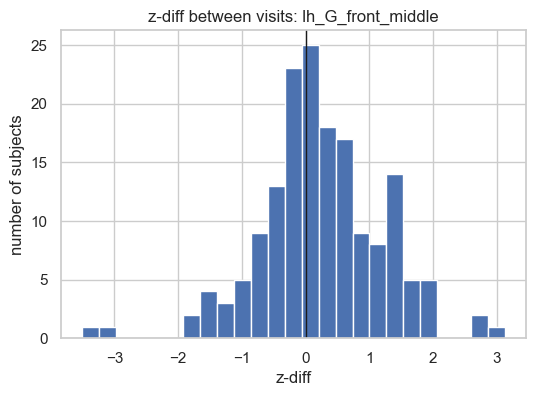

In [5]:
# Pick one region
region = response_vars[0]

# Plot the distribution of z-diff values across subjects.
plt.figure(figsize=(6, 4))
plt.hist(
    zdiff_scores.sel(response_vars=region).values,
    bins=25,
    color="#4c72b0",
    edgecolor="white",
)

# Mark zero, which corresponds to typical change.
plt.axvline(0, color="k", lw=1)
plt.xlabel("z-diff")
plt.ylabel("number of subjects")
plt.title(f"z-diff between visits: {region}")
plt.show()

## 4a. z-gain

`ZGainScore` asks whether a subject's z-score at the later visit is surprising given their earlier visit. It relies on how strongly z-scores are correlated across ages, which it estimates as a **correlation matrix**.

In [6]:
zgain = ZGainScore(
    normative_model=model,
    reference_data=longitudinal_data,
    subject_id_col="sub_id",
    bandwidth=5,
    covariate="age",
)

# In this toy example, the score data are the same as the reference data. We
# could also split use score data = patients and 
# reference data = healthy controls.
zgain_scores = zgain.score(
    score_data=longitudinal_data,
    subject_id_col="sub_id",
    timepoint_col="visit",
)

# Show the first few subject-level z-gain scores.
zgain_scores.to_dataframe(name="z_gain").unstack("response_vars").head()

z_gain                        
response_vars lh_G_front_middle lh_G_and_S_frontomargin
subjects                                               
C000                   2.811243               -5.068195
C001                  -2.354292               -0.245577
C002                   1.368538                2.709680
C003                  -0.733070                0.523608
C004                   1.525117                0.399801

# 4b. Plot the correlation matrix

The heatmap below shows the **full** age-to-age z-score correlation
matrix. A note on how to read it:

- For age pairs that the reference cohort actually covers (here roughly
  18–50), the correlation is estimated **directly** from subjects seen at
  both ages.
- For age pairs outside that range, there are no paired observations, so
  the value is **extrapolated** by the Buuren (2023) regression model
  fitted to the Fisher-transformed correlations (see
  [`velocity.py`](../pcntoolkit/math_functions/velocity.py)).

The extrapolated region is mathematically smooth and internally
consistent, but it is **not data-driven** — treat correlations far
outside the sampled age range with caution.

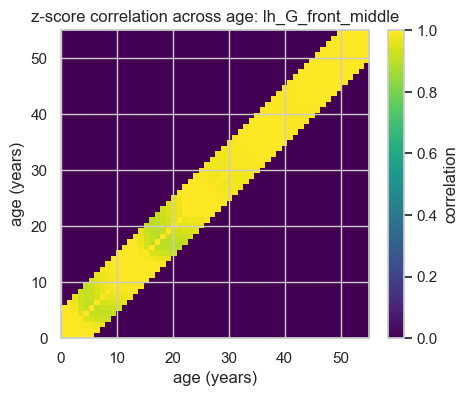

In [7]:
# The learned correlation matrix is stored after z-gain is computed.
R = zgain.correlation_matrix.sel(response_vars=region)

# Read the integer ages used on both matrix axes.
ages = R["age_1"].values

# Display the full age-to-age z-score correlation matrix as a heatmap.
plt.figure(figsize=(5, 4))
plt.imshow(
    R.values,
    origin="lower",
    extent=[ages.min(), ages.max(), ages.min(), ages.max()],
    vmin=0,
    vmax=1,
    cmap="viridis",
)
plt.colorbar(label="correlation")
plt.xlabel("age (years)")
plt.ylabel("age (years)")
plt.title(f"z-score correlation across age: {region}")
plt.show()

## 5. Are the results as expected?

For this reference population we expect:

- z-diff scores centred near 0 (most people change a typical amount),
- z-diff and z-gain to broadly **agree** on who shows unusual change, since both measure the same thing on this two-visit data.

z-diff: mean = 0.24, sd = 0.97
z-gain: mean = 0.32, sd = 1.68
agreement (same direction): 99%


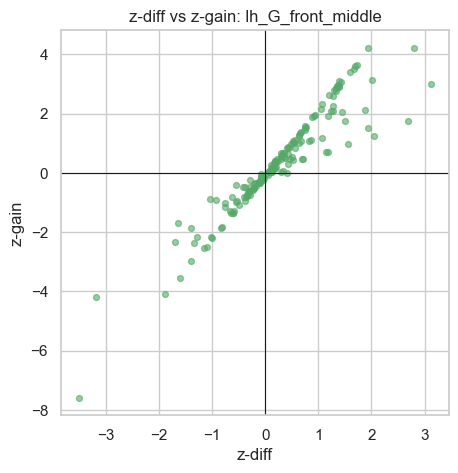

In [8]:
# Read the two longitudinal scores for one region.
zd = zdiff_scores.sel(response_vars=region).values
zg = zgain_scores.sel(response_vars=region).values

# Keep only subjects with finite values in both scores.
ok = np.isfinite(zd) & np.isfinite(zg)

# Summarise the location and spread of the two score distributions.
print(f"z-diff: mean = {zd[ok].mean():.2f}, sd = {zd[ok].std():.2f}")
print(f"z-gain: mean = {zg[ok].mean():.2f}, sd = {zg[ok].std():.2f}")
print(
    "agreement (same direction): "
    f"{np.mean(np.sign(zd[ok]) == np.sign(zg[ok])):.0%}"
)

# Plot the subject-level agreement between z-diff and z-gain.
plt.figure(figsize=(5, 5))
plt.scatter(zd[ok], zg[ok], s=18, alpha=0.6, color="#55a868")
plt.axhline(0, color="k", lw=0.8)
plt.axvline(0, color="k", lw=0.8)
plt.xlabel("z-diff")
plt.ylabel("z-gain")
plt.title(f"z-diff vs z-gain: {region}")
plt.show()

## Choosing between z-diff and z-gain
 
| You have…                              | Use          |
|----------------------------------------|--------------|
| Two timepoints, BLR model              | `ZDiffScore` — simpler, scalar variance estimate |
| Two timepoints, want thrive lines      | `ZGainScore` |
| Three or more timepoints               | `ZGainScore` (z-diff doesn't generalise) |
| Want to forecast future visits         | `ZGainScore.conditional_forecast()` |
 

A large positive or negative score flags a subject whose change over time is unusual compared with the reference population -- could be a useful metric to find atypical trajectories in clinical populations.

# 6. A clinical split: controls as reference, patients as score data

So far we used the same cohort to *learn* typical change and to *display*
the scores. In a real study the reference cohort should be **healthy
controls**, and we score a separate **patient** group against it.

`LNM_data` carries a `group` column with two values:

- `control` — 67 subjects (ids beginning with `C`), two visits each,
- `patient` — 98 subjects (ids beginning with `P`), two visits each.

We now:

1. fit the z-diff / z-gain reference distribution on **controls only**,
2. score the **patients**,
3. compare the score distributions of the two groups.

If the disease drives atypical change over time, patients should show a
**wider spread** of z-diff / z-gain and more subjects in the tails than
controls.

In [9]:
# Split the longitudinal cohort on the disease-status column.
control_df = longitudinal_df[longitudinal_df["group"] == "control"]
patient_df = longitudinal_df[longitudinal_df["group"] == "patient"]


def make_predicted_normdata(name, frame):
    """Build a NormData from a frame and attach model predictions."""
    # Wrap the raw frame in the toolkit data container.
    data = NormData.from_dataframe(
        name=name,
        dataframe=frame,
        covariates=["age"],
        batch_effects=None,
        response_vars=response_vars,
        subject_ids="sub_id",
    )
    # Predictions (Yhat, Z) are required before longitudinal scoring.
    return model.predict(data)


# Controls become the reference cohort; patients are scored against it.
control_data = make_predicted_normdata("control", control_df)
patient_data = make_predicted_normdata("patient", patient_df)

Process: 36380 - 2026-06-10 18:08:02 - Dataset "control" created.
    - 134 observations
    - 67 unique subjects
    - 1 covariates
    - 2 response variables
    - 1 batch effects:
    	dummy_batch_effect (1)
    
Process: 36380 - 2026-06-10 18:08:02 - Making predictions on 2 response variables.
Process: 36380 - 2026-06-10 18:08:02 - Computing z-scores for 2 response variables.
Process: 36380 - 2026-06-10 18:08:02 - Computing z-scores for lh_G_and_S_frontomargin.
Process: 36380 - 2026-06-10 18:08:02 - Computing z-scores for lh_G_front_middle.
Process: 36380 - 2026-06-10 18:08:02 - Computing centiles for 2 response variables.
Process: 36380 - 2026-06-10 18:08:02 - Computing centiles for lh_G_and_S_frontomargin.
Process: 36380 - 2026-06-10 18:08:02 - Computing centiles for lh_G_front_middle.
Process: 36380 - 2026-06-10 18:08:02 - Computing log-probabilities for 2 response variables.
Process: 36380 - 2026-06-10 18:08:02 - Computing log-probabilities for 2 response variables.
Process: 36

Process: 36380 - 2026-06-10 18:08:02 - Computing yhat for lh_G_front_middle.


Process: 36380 - 2026-06-10 18:08:03 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 2 response variables
    - 1 batch effects:
    	dummy_batch_effect (1)
    
Process: 36380 - 2026-06-10 18:08:03 - Computing centiles for 2 response variables.
Process: 36380 - 2026-06-10 18:08:03 - Computing centiles for lh_G_and_S_frontomargin.
Process: 36380 - 2026-06-10 18:08:03 - Computing centiles for lh_G_front_middle.
Process: 36380 - 2026-06-10 18:08:03 - Harmonizing data on 2 response variables.
Process: 36380 - 2026-06-10 18:08:03 - Harmonizing data for lh_G_and_S_frontomargin.
Process: 36380 - 2026-06-10 18:08:03 - Harmonizing data for lh_G_front_middle.


Process: 36380 - 2026-06-10 18:08:03 - Dataset "patient" created.
    - 196 observations
    - 98 unique subjects
    - 1 covariates
    - 2 response variables
    - 1 batch effects:
    	dummy_batch_effect (1)
    
Process: 36380 - 2026-06-10 18:08:03 - Making predictions on 2 response variables.
Process: 36380 - 2026-06-10 18:08:03 - Computing z-scores for 2 response variables.
Process: 36380 - 2026-06-10 18:08:03 - Computing z-scores for lh_G_and_S_frontomargin.
Process: 36380 - 2026-06-10 18:08:03 - Computing z-scores for lh_G_front_middle.
Process: 36380 - 2026-06-10 18:08:03 - Computing centiles for 2 response variables.
Process: 36380 - 2026-06-10 18:08:03 - Computing centiles for lh_G_and_S_frontomargin.
Process: 36380 - 2026-06-10 18:08:03 - Computing centiles for lh_G_front_middle.
Process: 36380 - 2026-06-10 18:08:03 - Computing log-probabilities for 2 response variables.
Process: 36380 - 2026-06-10 18:08:03 - Computing log-probabilities for 2 response variables.
Process: 36

Process: 36380 - 2026-06-10 18:08:04 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 2 response variables
    - 1 batch effects:
    	dummy_batch_effect (1)
    
Process: 36380 - 2026-06-10 18:08:04 - Computing centiles for 2 response variables.
Process: 36380 - 2026-06-10 18:08:04 - Computing centiles for lh_G_and_S_frontomargin.
Process: 36380 - 2026-06-10 18:08:04 - Computing centiles for lh_G_front_middle.
Process: 36380 - 2026-06-10 18:08:04 - Harmonizing data on 2 response variables.
Process: 36380 - 2026-06-10 18:08:04 - Harmonizing data for lh_G_and_S_frontomargin.
Process: 36380 - 2026-06-10 18:08:04 - Harmonizing data for lh_G_front_middle.


In [10]:
# Build both scorers using CONTROLS as the reference cohort.
zdiff_clin = ZDiffScore(
    normative_model=model,
    reference_data=control_data,
    subject_id_col="sub_id",
)
zgain_clin = ZGainScore(
    normative_model=model,
    reference_data=control_data,
    subject_id_col="sub_id",
    bandwidth=5,
    covariate="age",
)

# Score controls and patients with the same control-based reference.
zdiff_control = zdiff_clin.score(score_data=control_data, timepoint_col="visit")
zdiff_patient = zdiff_clin.score(score_data=patient_data, timepoint_col="visit")
zgain_control = zgain_clin.score(score_data=control_data, timepoint_col="visit")
zgain_patient = zgain_clin.score(score_data=patient_data, timepoint_col="visit")

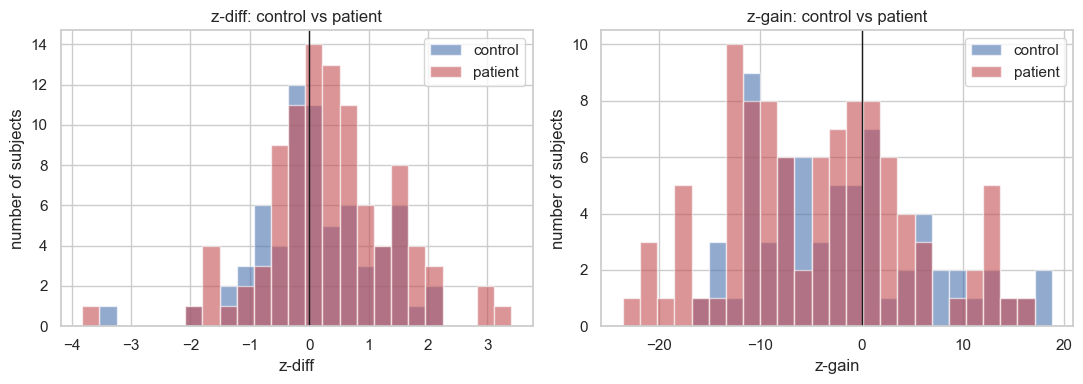

z-diff: control SD = 0.99, patient SD = 1.09
z-gain: control SD = 8.53, patient SD = 9.05


In [11]:
# Compare the control and patient score distributions for one region.
region = response_vars[0]


def finite_values(score, region):
    """Return the finite scores for one region as a 1D array."""
    # Drop NaNs left by single-visit or out-of-range subjects.
    values = score.sel(response_vars=region).values
    return values[np.isfinite(values)]


# Plot z-diff (left) and z-gain (right) for controls vs patients.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
panels = [
    ("z-diff", zdiff_control, zdiff_patient),
    ("z-gain", zgain_control, zgain_patient),
]
for ax, (label, control_score, patient_score) in zip(axes, panels):
    # Pull the finite scores for each group.
    ctrl = finite_values(control_score, region)
    pat = finite_values(patient_score, region)
    # Share one set of bins so the two groups line up.
    bins = np.histogram_bin_edges(np.concatenate([ctrl, pat]), bins=25)
    # Overlay the two distributions.
    ax.hist(ctrl, bins=bins, alpha=0.6, label="control", color="#4c72b0")
    ax.hist(pat, bins=bins, alpha=0.6, label="patient", color="#c44e52")
    # Mark the typical-change line at zero.
    ax.axvline(0, color="k", lw=1)
    ax.set_xlabel(label)
    ax.set_ylabel("number of subjects")
    ax.set_title(f"{label}: control vs patient")
    ax.legend()
plt.tight_layout()
plt.show()

# Print the spread (SD) of each group for both scores.
for label, control_score, patient_score in panels:
    ctrl = finite_values(control_score, region)
    pat = finite_values(patient_score, region)
    print(
        f"{label}: control SD = {ctrl.std():.2f}, "
        f"patient SD = {pat.std():.2f}"
    )

### What do we see?

For this region the spreads come out roughly as:

| score | control SD | patient SD |
| --- | --- | --- |
| z-diff | ~1.0 | ~1.1 |
| z-gain | ~8.5 | ~9.0 |

Two things to read from this:

- **Patients are slightly more variable than controls** on both scores,
  which is the direction we expect if the disease adds atypical change on
  top of normal ageing. The effect here is modest because this is a small
  toy dataset.
- **z-diff is well calibrated, z-gain is not, in this split.** z-diff has
  a control SD near 1 because its denominator is estimated directly from
  the control change distribution. z-gain instead divides by
  `sqrt(1 − r²)`, where `r` comes from the age-to-age correlation matrix.
  With only 67 control subjects that matrix is estimated from few pairs
  per age, so some correlations land close to 1, the denominator becomes
  tiny, and z-gain inflates.

**Takeaway:** z-gain needs a reasonably large, well-sampled reference
cohort to estimate a stable correlation matrix. When the reference is
small (as when restricting to controls in a small study), prefer z-diff,
or widen the `bandwidth` / lower `max_correlation` to stabilise the
denominator.